# Introduction to NeuralHydrology

There are two different ways to use the Python package NeuralHydrology:

1. From the terminal, making use of some high-level entry points (such as `nh-run` and `nh-schedule-runs`)
2. From any other Python file or Jupyter Notebook, using NeuralHydrology's API

For every run that you start, a new folder will be created. This folder is used to store the model and optimizer checkpoints, train data means/stds (needed for scaling during inference), tensorboard log file (can be used to monitor and compare training runs visually), validation results (optionally) and training progress figures (optionally, e.g., model predictions and observations for _n_ random basins). During inference, the evaluation results will also be stored in this directory (e.g., test period results).


### TensorBoard logging
By default, the training progress is logged in TensorBoard files (add `log_tensorboard: False` to the config to disable TensorBoard logging).

To start the TensorBoard dashboard, run:

```
tensorboard --logdir /path/to/run-dir
```

You can also visualize multiple runs at once if you point the `--logdir` to the parent directory (useful for model intercomparison)

## Using NeuralHydrology from the Terminal

### nh-run


Given a run configuration file, you can use the bash command `nh-run` to train/evaluate a model. To train a model, use


```bash
nh-run train --config-file path/to/config.yml
```

to evaluate the model after training, use

```bash
nh-run evaluate --run-dir path/to/run-directory
```

### nh-schedule-runs

If you want to train/evaluate multiple models on different GPUs, you can use the `nh-schedule-runs` command. This tool automatically distributes runs across GPUs and starts a new one, whenever one run finishes.

Calling `nh-schedule-runs` in `train` mode will train one model for each `.yml` file in a directory (or its sub-directories).

```bash
nh-schedule-runs train --directory /path/to/config-dir --runs-per-gpu 2 --gpu_ids 0 1 2 3 
```
Use `-runs-per-gpu` to define the number of models that are simultaneously trained on a _single_ GPU (2 in this case) and `--gpu-ids` to define which GPUs will be used (numbers are ids according to nvidia-smi). In this example, 8 models will train simultaneously on 4 different GPUs.

Calling `nh-schedule-runs` in `evaluate` mode will evaluate all models in all run directories in a given root directory.

```bash
nh-schedule-runs evaluate --directory /path/to/parent-run-dir/ --runs-per-gpu 2 --gpu_ids 0 1 2 3 
```

## Links
A full list of config arguments is listed in the [documentation](https://neuralhydrology.readthedocs.io/en/latest/usage/config.html)

Look at the [API Documentation](https://neuralhydrology.readthedocs.io/en/latest/api/neuralhydrology.html) for a full list of functions/classes you could use.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'

### Train a model for a single config file

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [42]:
! ls /global/home/users/ann_scheliga/neuralhydrology/runs/

EXP00_1basin_cbr_no_sw_0508_101608
EXP00_1basin_cbr_wi_sw_0508_100309
notebook_lstm_preprocess_input_2707_173454
notebook_lstm_preprocess_input_2707_174001
notebook_lstm_preprocess_input_2707_174032
notebook_lstm_preprocess_input_2707_174530
notebook_lstm_preprocess_input_2707_174636
notebook_lstm_preprocess_input_2707_174906
notebook_lstm_preprocess_input_2707_174926
notebook_two_var_only_0907_131306
notebook_two_var_only_0907_142954


## EVALUATION

In [60]:
sw_run_dir = Path(all_runs_dir,"EXP00_1basin_cbr_wi_sw_0508_100309")
print(sw_run_dir)
eval_run(run_dir=sw_run_dir, period="test")
eval_run(run_dir=sw_run_dir, period="train")
eval_run(run_dir=sw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_1basin_cbr_wi_sw_0508_100309
# Validation: 100%|██████████| 1/1 [00:00<00:00, 14.67it/s]


In [61]:
nosw_run_dir = Path(all_runs_dir,"EXP00_1basin_cbr_no_sw_0508_101608")
print(nosw_run_dir)
eval_run(run_dir=nosw_run_dir, period="test")
eval_run(run_dir=nosw_run_dir, period="train")
eval_run(run_dir=nosw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_1basin_cbr_no_sw_0508_101608
# Validation: 100%|██████████| 1/1 [00:00<00:00, 15.56it/s]


### Load and inspect model predictions

In [64]:
with open(sw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    sw_train_results = pickle.load(fp)
    
sw_train_results.keys()

dict_keys(['4152450'])

In [65]:
with open(nosw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    nosw_train_results = pickle.load(fp)
    
nosw_train_results.keys()

dict_keys(['4152450'])

In [66]:
with open(sw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    sw_test_results = pickle.load(fp)
    
sw_test_results.keys()

dict_keys(['4152450'])

In [67]:
with open(nosw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    nosw_test_results = pickle.load(fp)
    
nosw_test_results.keys()

dict_keys(['4152450'])

In [72]:
def plot_obs_sim_timeseries(ax, nh_dict,period=''):
    qobs = nh_dict['xr']['Q_obs']
    qsim = nh_dict['xr']['Q_sim']
    
    ax.plot(qobs['date'], qobs, c='k',label='obs')
    ax.plot(qsim['date'], qsim, c='b',label='sim')
    ax.set_ylabel("Discharge (mm/d)")
    ax.set_title(f"{period} period - NSE {nh_dict['NSE']:.3f}")
    values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
    print('----',period, 'METRICS----')
    for key, val in values.items():
        print(f"{key}: {val:.3f}")

---- SW train METRICS----
NSE: 0.663
MSE: 823.678
RMSE: 28.700
KGE: 0.678
Alpha-NSE: 0.734
Beta-KGE: 1.001
Beta-NSE: 0.006
Pearson-r: 0.819
FHV: -16.305
FMS: -24.681
FLV: 85.858
Peak-Timing: 2.286
Peak-MAPE: 14.633
---- SW test METRICS----
NSE: -0.193
MSE: 30144.902
RMSE: 173.623
KGE: -0.318
Alpha-NSE: 0.103
Beta-KGE: 0.808
Beta-NSE: -0.440
Pearson-r: 0.053
FHV: -67.522
FMS: -90.387
FLV: 30.769
Peak-Timing: 0.000
Peak-MAPE: 73.741
---- No SW train METRICS----
NSE: 0.577
MSE: 1285.130
RMSE: 35.849
KGE: 0.575
Alpha-NSE: 0.643
Beta-KGE: 1.000
Beta-NSE: -0.002
Pearson-r: 0.770
FHV: -19.730
FMS: -23.087
FLV: 93.139
Peak-Timing: 1.778
Peak-MAPE: 17.575
---- No SW test METRICS----
NSE: -0.025
MSE: 25906.279
RMSE: 160.954
KGE: -0.283
Alpha-NSE: 0.037
Beta-KGE: 0.918
Beta-NSE: -0.188
Pearson-r: 0.156
FHV: -66.055
FMS: -97.893
FLV: 39.520
Peak-Timing: 0.000
Peak-MAPE: 69.895


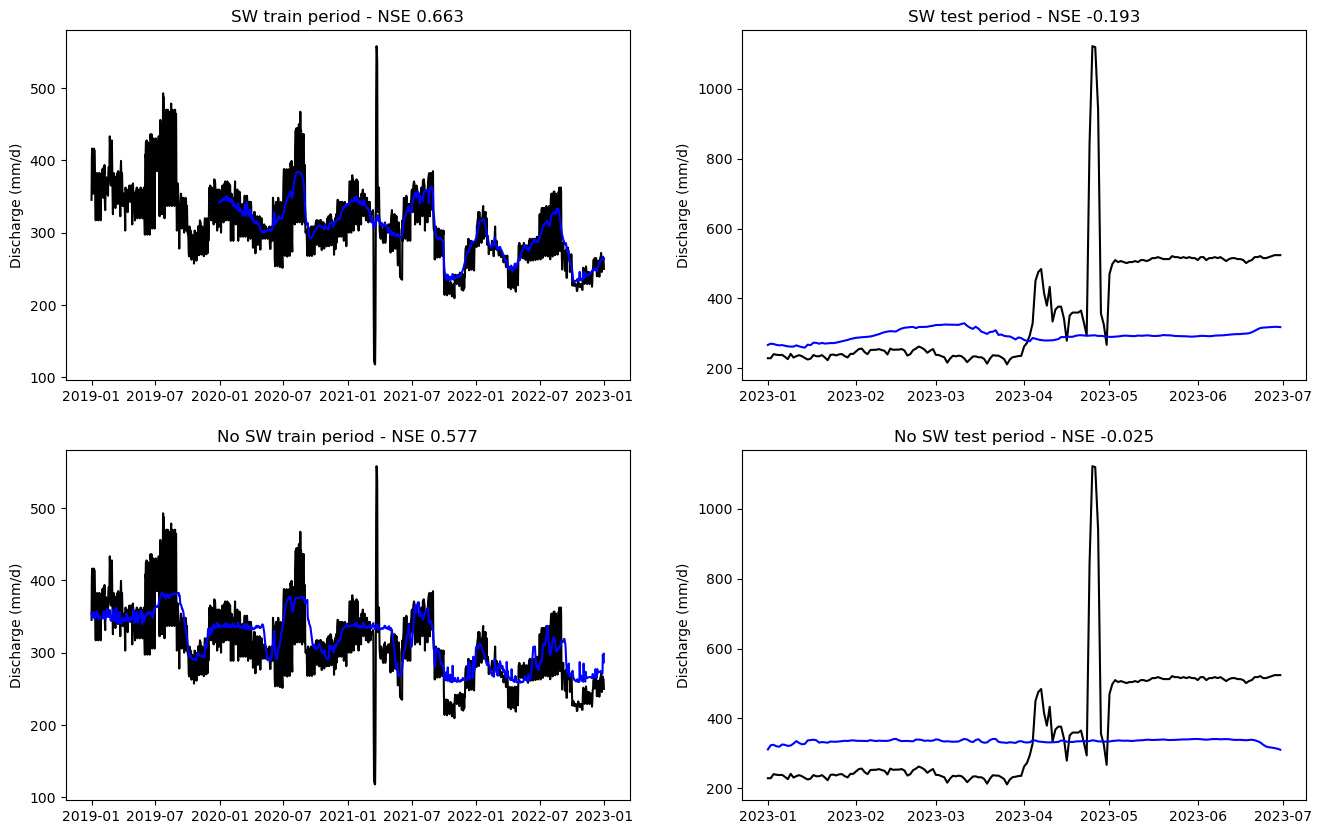

In [73]:
fig, axs = plt.subplots(2,2,figsize=(16,10))

plot_obs_sim_timeseries(axs[0,0],sw_train_results['4152450']['1D'],'SW train')
plot_obs_sim_timeseries(axs[0,1],sw_test_results['4152450']['1D'],'SW test')
plot_obs_sim_timeseries(axs[1,0],nosw_train_results['4152450']['1D'],'No SW train')
plot_obs_sim_timeseries(axs[1,1],nosw_test_results['4152450']['1D'],'No SW test')